In [1]:
# ============================================
# 0) Imports and module reload
# ============================================
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import c1_forecasting
import c3_forecasting

importlib.reload(c1_forecasting)
importlib.reload(c3_forecasting)

from c1_forecasting import run_c1_pipeline
from c3_forecasting import run_c3_pipeline


In [2]:
# ============================================
# 1) Run C1 pipeline
# ============================================
art_c1 = run_c1_pipeline(
    train_path="data/forecasting/train_daily.parquet",
    test_path="data/forecasting/test_daily.parquet",
    cluster_id=1,
    n_periods=4,
    eps_mape=1.0,
    metric_name="bounded_mape",      # reporting metric
    tune=True,
    tuning_objective="wmape",        # optimization objective
    max_trials_per_model_pair=600,   # can increase to 800/1000
    prediction_output_path="data/forecasting/c1_prediction.parquet",
    random_state=42,
)

print("C1 prediction file:", art_c1.prediction_output_path)
print("\n=== C1 Overall Metrics ===")
display(art_c1.metrics_overall)

print("\n=== C1 Metrics by Period ===")
display(art_c1.metrics_by_period)

if art_c1.tuning_trials is not None:
    print("\n=== C1 Top tuning trials ===")
    display(art_c1.tuning_trials.head(10))

print("\n=== C1 Best Config ===")
print(art_c1.tuning_best_config)

display(art_c1.error_quantiles)

C1 prediction file: data/forecasting/c1_prediction.parquet

=== C1 Overall Metrics ===


,method,MAPE_0_100,EPSILON_MAPE_PCT,CAP_MAPE_0_100,POSITIVE_ONLY_MAPE_PCT,WMAPE_0_100,OCCURRENCE_F1,ZERO_DAY_FPR
1,two_stage_hgb,15.565231,38.547142,15.565231,153.942877,67.691523,0.998925,0.000736
0,snaive7,28.671702,270.261428,28.671702,177.476860,111.075906,0.643757,0.118024



=== C1 Metrics by Period ===


,method,period,MAPE_0_100,EPSILON_MAPE_PCT,CAP_MAPE_0_100,POSITIVE_ONLY_MAPE_PCT,WMAPE_0_100,OCCURRENCE_F1,ZERO_DAY_FPR
0,snaive7,P1,26.469093,250.089604,26.469093,173.319443,127.565350,0.553068,0.116692
1,snaive7,P2,26.309126,327.832906,26.309126,193.538765,135.030269,0.537762,0.117831
2,snaive7,P3,30.474432,281.870154,30.474432,185.609660,117.715818,0.657901,0.123284
3,snaive7,P4,31.482038,221.691567,31.482038,163.232151,89.706764,0.758066,0.114194
4,two_stage_hgb,P1,13.287858,36.583560,13.287858,157.570328,72.188298,0.994889,0.002734
5,two_stage_hgb,P2,12.492979,29.558897,12.492979,150.817198,71.613730,1.000000,0.000000
6,two_stage_hgb,P3,17.031732,42.826436,17.031732,161.659424,70.877508,1.000000,0.000000
7,two_stage_hgb,P4,19.497864,45.262360,19.497864,147.007217,62.019334,1.000000,0.000000



=== C1 Top tuning trials ===


,score,objective_value,objective_name,metric_mape,metric_wmape,metric_pos_mape,peak_under_penalty,volatility_penalty,cls_params,reg_params,tau,alpha,cap_q,cap_value,peak_prob_threshold,peak_mult,smooth_gamma
0,73.207592,65.681545,wmape,11.277337,65.681545,3.053939e+11,62.71706,0.0,"{'max_depth': 4, 'learning_rate': 0.05, 'max_i...","{'loss': 'squared_error', 'max_depth': 6, 'lea...",0.10,1.0,1.000,inf,0.85,1.05,0.0
1,73.207592,65.681545,wmape,11.277337,65.681545,3.053939e+11,62.71706,0.0,"{'max_depth': 4, 'learning_rate': 0.05, 'max_i...","{'loss': 'squared_error', 'max_depth': 6, 'lea...",0.05,1.0,0.999,1486.91508,0.80,1.05,0.0
2,73.207592,65.681545,wmape,11.277337,65.681545,3.053939e+11,62.71706,0.0,"{'max_depth': 4, 'learning_rate': 0.05, 'max_i...","{'loss': 'squared_error', 'max_depth': 6, 'lea...",0.15,1.0,1.000,inf,0.85,1.05,0.0
3,73.207592,65.681545,wmape,11.277337,65.681545,3.053939e+11,62.71706,0.0,"{'max_depth': 4, 'learning_rate': 0.05, 'max_i...","{'loss': 'squared_error', 'max_depth': 6, 'lea...",0.05,1.0,0.999,1486.91508,0.85,1.05,0.0
4,73.207592,65.681545,wmape,11.277337,65.681545,3.053939e+11,62.71706,0.0,"{'max_depth': 4, 'learning_rate': 0.05, 'max_i...","{'loss': 'squared_error', 'max_depth': 6, 'lea...",0.20,1.0,1.000,inf,0.80,1.05,0.0
5,73.207592,65.681545,wmape,11.277337,65.681545,3.053939e+11,62.71706,0.0,"{'max_depth': 4, 'learning_rate': 0.05, 'max_i...","{'loss': 'squared_error', 'max_depth': 6, 'lea...",0.15,1.0,0.999,1486.91508,0.85,1.05,0.0
6,73.207592,65.681545,wmape,11.277337,65.681545,3.053939e+11,62.71706,0.0,"{'max_depth': 4, 'learning_rate': 0.05, 'max_i...","{'loss': 'squared_error', 'max_depth': 6, 'lea...",0.10,1.0,1.000,inf,0.80,1.05,0.0
7,73.207592,65.681545,wmape,11.277337,65.681545,3.053939e+11,62.71706,0.0,"{'max_depth': 4, 'learning_rate': 0.05, 'max_i...","{'loss': 'squared_error', 'max_depth': 6, 'lea...",0.10,1.0,0.995,644.77780,0.85,1.05,0.0
8,73.207592,65.681545,wmape,11.277337,65.681545,3.053939e+11,62.71706,0.0,"{'max_depth': 4, 'learning_rate': 0.05, 'max_i...","{'loss': 'squared_error', 'max_depth': 6, 'lea...",0.10,1.0,0.995,644.77780,0.90,1.05,0.0
9,73.207592,65.681545,wmape,11.277337,65.681545,3.053939e+11,62.71706,0.0,"{'max_depth': 4, 'learning_rate': 0.05, 'max_i...","{'loss': 'squared_error', 'max_depth': 6, 'lea...",0.15,1.0,0.995,644.77780,0.85,1.05,0.0



=== C1 Best Config ===
{'cls_params': {'max_depth': 4, 'learning_rate': 0.05, 'max_iter': 300, 'min_samples_leaf': 60}, 'reg_params': {'loss': 'squared_error', 'max_depth': 6, 'learning_rate': 0.04, 'max_iter': 500, 'min_samples_leaf': 30}, 'tau': 0.1, 'alpha': 1.0, 'cap_q': 0.995, 'cap_value': 644.7778000000026, 'peak_prob_threshold': 0.9, 'peak_mult': 1.05, 'smooth_gamma': 0.0}


,method,period,count,q50,q75,q90,q95,q99,mean
0,snaive7,P1,22231,0.0,70.362103,100.000000,100.0,100.0,26.469093
1,snaive7,P2,21758,0.0,69.963991,100.000000,100.0,100.0,26.309126
2,snaive7,P3,21758,0.0,91.666667,100.000000,100.0,100.0,30.474432
3,snaive7,P4,21758,0.0,83.673968,100.000000,100.0,100.0,31.482038
4,two_stage_hgb,P1,22231,0.0,0.000000,67.315790,100.0,100.0,13.287858
5,two_stage_hgb,P2,21758,0.0,0.000000,62.781567,100.0,100.0,12.492979
6,two_stage_hgb,P3,21758,0.0,13.031925,83.085131,100.0,100.0,17.031732
7,two_stage_hgb,P4,21758,0.0,28.817280,90.812166,100.0,100.0,19.497864


In [3]:
# ============================================
# 2) Run C3 pipeline
# ============================================
art_c3 = run_c3_pipeline(
    train_path="data/forecasting/train_daily.parquet",
    test_path="data/forecasting/test_daily.parquet",
    cluster_id=3,
    n_periods=4,
    eps_mape=1.0,
    metric_name="bounded_mape",      # reporting metric
    tune=True,
    tuning_objective="wmape",        # optimization objective
    max_trials_per_model_pair=600,   # can increase to 800/1000
    prediction_output_path="data/forecasting/c3_prediction.parquet",
    random_state=42,
)

print("C3 prediction file:", art_c3.prediction_output_path)
print("\n=== C3 Selected Baseline ===")
print(art_c3.selected_baseline_name)
display(art_c3.baseline_comparison)

print("\n=== C3 Overall Metrics ===")
display(art_c3.metrics_overall)

print("\n=== C3 Metrics by Period ===")
display(art_c3.metrics_by_period)

if art_c3.tuning_trials is not None:
    print("\n=== C3 Top tuning trials ===")
    display(art_c3.tuning_trials.head(10))

print("\n=== C3 Best Config ===")
print(art_c3.tuning_best_config)

display(art_c3.error_quantiles)

C3 prediction file: data/forecasting/c3_prediction.parquet

=== C3 Selected Baseline ===
adida


,baseline,score
0,adida,20.158053
1,tsb,42.716672
2,sba,81.708924



=== C3 Overall Metrics ===


,method,MAPE_0_100,EPSILON_MAPE_PCT,CAP_MAPE_0_100,POSITIVE_ONLY_MAPE_PCT,WMAPE_0_100,OCCURRENCE_F1,ZERO_DAY_FPR
1,two_stage_hgb,5.808878,14.124957,5.808878,181.855302,78.825801,0.997796,0.000228
0,adida,18.634981,56.768889,18.634981,97.336392,122.659748,0.290099,0.149164



=== C3 Metrics by Period ===


,method,period,MAPE_0_100,EPSILON_MAPE_PCT,CAP_MAPE_0_100,POSITIVE_ONLY_MAPE_PCT,WMAPE_0_100,OCCURRENCE_F1,ZERO_DAY_FPR
0,adida,P1,17.907483,54.000274,17.907483,98.014357,125.613938,0.307182,0.146729
1,adida,P2,17.021389,57.576229,17.021389,97.621761,137.790957,0.261420,0.152736
2,adida,P3,18.432754,57.323680,18.432754,96.835399,122.786294,0.265126,0.152639
3,adida,P4,21.194115,58.235560,21.194115,97.047833,114.204736,0.319592,0.144317
4,two_stage_hgb,P1,5.624163,13.775150,5.624163,179.346613,77.730174,0.993469,0.000891
5,two_stage_hgb,P2,4.140645,10.117789,4.140645,181.855065,76.172922,0.999347,0.000000
6,two_stage_hgb,P3,5.526023,13.867514,5.526023,192.746327,81.605017,0.997939,0.000000
7,two_stage_hgb,P4,7.948698,18.746978,7.948698,176.283230,78.679280,0.999914,0.000000



=== C3 Top tuning trials ===


,score,objective_value,objective_name,metric_mape,metric_wmape,positive_only_mape,peak_under_penalty,volatility_under_penalty,cls_params,reg_params,tau,alpha,cap_q,cap_value,y_floor,peak_prob_threshold,peak_mult,vol_scale
0,93.175989,76.996514,wmape,4.801724,76.996514,160.764259,75.433407,48.644637,"{'max_depth': 3, 'learning_rate': 0.03, 'max_i...","{'loss': 'squared_error', 'max_depth': 4, 'lea...",0.10,0.9,1.000,inf,0.25,0.7,1.2,0.0
1,93.175989,76.996514,wmape,4.801724,76.996514,160.764259,75.433407,48.644637,"{'max_depth': 3, 'learning_rate': 0.03, 'max_i...","{'loss': 'squared_error', 'max_depth': 4, 'lea...",0.15,0.9,0.999,1204.7628,0.00,0.9,1.2,0.0
2,93.175989,76.996514,wmape,4.801724,76.996514,160.764259,75.433407,48.644637,"{'max_depth': 3, 'learning_rate': 0.03, 'max_i...","{'loss': 'squared_error', 'max_depth': 4, 'lea...",0.05,0.9,1.000,inf,0.00,0.8,1.2,0.0
3,93.175989,76.996514,wmape,4.801724,76.996514,160.764259,75.433407,48.644637,"{'max_depth': 3, 'learning_rate': 0.03, 'max_i...","{'loss': 'squared_error', 'max_depth': 4, 'lea...",0.05,0.9,0.995,373.9472,0.50,0.8,1.2,0.0
4,93.175989,76.996514,wmape,4.801724,76.996514,160.764259,75.433407,48.644637,"{'max_depth': 3, 'learning_rate': 0.03, 'max_i...","{'loss': 'squared_error', 'max_depth': 4, 'lea...",0.10,0.9,0.995,373.9472,0.50,0.7,1.2,0.0
5,93.175989,76.996514,wmape,4.801724,76.996514,160.764259,75.433407,48.644637,"{'max_depth': 3, 'learning_rate': 0.03, 'max_i...","{'loss': 'squared_error', 'max_depth': 4, 'lea...",0.15,0.9,0.995,373.9472,0.50,0.8,1.2,0.0
6,93.175989,76.996514,wmape,4.801724,76.996514,160.764259,75.433407,48.644637,"{'max_depth': 3, 'learning_rate': 0.03, 'max_i...","{'loss': 'squared_error', 'max_depth': 4, 'lea...",0.00,0.9,0.999,1204.7628,0.25,0.8,1.2,0.0
7,93.175989,76.996514,wmape,4.801724,76.996514,160.764259,75.433407,48.644637,"{'max_depth': 3, 'learning_rate': 0.03, 'max_i...","{'loss': 'squared_error', 'max_depth': 4, 'lea...",0.05,0.9,0.999,1204.7628,0.00,0.9,1.2,0.0
8,93.175989,76.996514,wmape,4.801724,76.996514,160.764259,75.433407,48.644637,"{'max_depth': 3, 'learning_rate': 0.03, 'max_i...","{'loss': 'squared_error', 'max_depth': 4, 'lea...",0.10,0.9,0.995,373.9472,0.00,0.9,1.2,0.0
9,93.175989,76.996514,wmape,4.801724,76.996514,160.764259,75.433407,48.644637,"{'max_depth': 3, 'learning_rate': 0.03, 'max_i...","{'loss': 'squared_error', 'max_depth': 4, 'lea...",0.10,0.9,0.999,1204.7628,0.00,0.8,1.2,0.0



=== C3 Best Config ===
{'cls_params': {'max_depth': 3, 'learning_rate': 0.03, 'max_iter': 250, 'min_samples_leaf': 120}, 'reg_params': {'loss': 'squared_error', 'max_depth': 4, 'learning_rate': 0.03, 'max_iter': 350, 'min_samples_leaf': 80}, 'tau': 0.05, 'alpha': 0.9, 'cap_q': 0.995, 'cap_value': 373.9471999999989, 'y_floor': 0.5, 'peak_prob_threshold': 0.8, 'peak_mult': 1.2, 'vol_scale': 0.0, 'vol_clip': 3.0}


,method,period,count,q50,q75,q90,q95,q99,mean
0,adida,P1,47799,0.0,0.000000,100.000000,100.000000,100.0,17.907483
1,adida,P2,46782,0.0,0.000000,100.000000,100.000000,100.0,17.021389
2,adida,P3,46782,0.0,0.000000,100.000000,100.000000,100.0,18.432754
3,adida,P4,46782,0.0,5.928571,100.000000,100.000000,100.0,21.194115
4,two_stage_hgb,P1,47799,0.0,0.000000,0.000000,58.082990,100.0,5.624163
5,two_stage_hgb,P2,46782,0.0,0.000000,0.000000,31.238667,100.0,4.140645
6,two_stage_hgb,P3,46782,0.0,0.000000,0.000000,56.028960,100.0,5.526023
7,two_stage_hgb,P4,46782,0.0,0.000000,25.830384,85.684733,100.0,7.948698


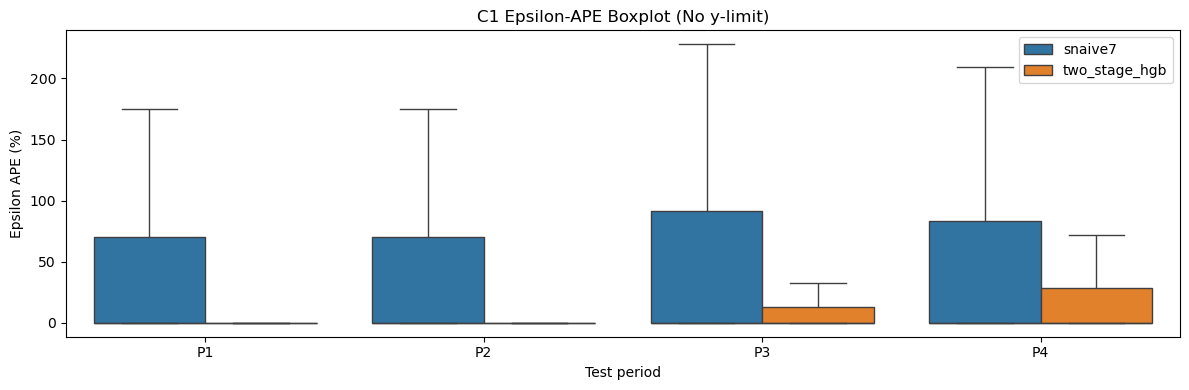

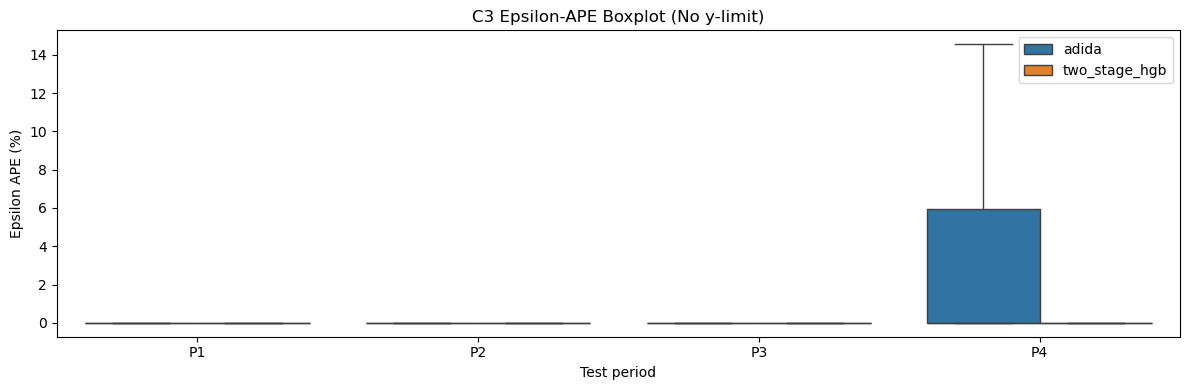

In [4]:
# ============================================
# 3) Box plots (error spread by period)
#    - one figure for C1
#    - one figure for C3
# ============================================
# C1
plt.figure(figsize=(12,4))
sns.boxplot(
    data=art_c1.ape_box_df,
    x="period",
    y="APE_EPS_PCT",
    hue="method",
    showfliers=False
)
plt.title("C1 Epsilon-APE Boxplot (No y-limit)")
plt.ylabel("Epsilon APE (%)")
plt.xlabel("Test period")
plt.legend(title="")
plt.tight_layout()
plt.show()

# C3
plt.figure(figsize=(12,4))
sns.boxplot(
    data=art_c3.ape_box_df,
    x="period",
    y="APE_EPS_PCT",
    hue="method",
    showfliers=False
)
plt.title("C3 Epsilon-APE Boxplot (No y-limit)")
plt.ylabel("Epsilon APE (%)")
plt.xlabel("Test period")
plt.legend(title="")
plt.tight_layout()
plt.show()

C1 period MAPE (0-100):


method,period,snaive7,two_stage_hgb
0,P1,26.469093,13.287858
1,P2,26.309126,12.492979
2,P3,30.474432,17.031732
3,P4,31.482038,19.497864


C3 period MAPE (0-100):


method,period,adida,two_stage_hgb
0,P1,17.907483,5.624163
1,P2,17.021389,4.140645
2,P3,18.432754,5.526023
3,P4,21.194115,7.948698


c1_pred shape: (87505, 10)
c3_pred shape: (188145, 12)


,date,product_family_name,cluster,y,is_sale,pred_snaive7,p_sale,pred_pos_if_sale,pred_two_stage,period
0,2011-06-08,10 COLOUR SPACEBOY PEN,1,2.46,1,10.2,9.999995e-01,10.962069,11.510167,P1
1,2011-06-09,10 COLOUR SPACEBOY PEN,1,0.00,0,0.0,8.978333e-08,9.378949,0.000000,P1
2,2011-06-10,10 COLOUR SPACEBOY PEN,1,40.80,1,0.0,9.999995e-01,9.968641,10.467067,P1
3,2011-06-11,10 COLOUR SPACEBOY PEN,1,0.00,0,0.0,8.978333e-08,14.586176,0.000000,P1
4,2011-06-12,10 COLOUR SPACEBOY PEN,1,0.00,0,0.0,8.978333e-08,10.853910,0.000000,P1


,date,product_family_name,cluster,y,is_sale,pred_tsb,pred_sba,pred_adida,p_sale,pred_pos_if_sale,pred_two_stage,period
0,2011-06-08,12 ASS ZINC CHRISTMAS DECORATIONS,3,0.0,0,3.000182e-11,3.373887,0.0,0.000059,9.867531,0.0,P1
1,2011-06-09,12 ASS ZINC CHRISTMAS DECORATIONS,3,0.0,0,3.000182e-11,3.373887,0.0,0.000059,10.329224,0.0,P1
2,2011-06-10,12 ASS ZINC CHRISTMAS DECORATIONS,3,0.0,0,3.000182e-11,3.373887,0.0,0.000059,9.706758,0.0,P1
3,2011-06-11,12 ASS ZINC CHRISTMAS DECORATIONS,3,0.0,0,3.000182e-11,3.373887,0.0,0.000059,9.958323,0.0,P1
4,2011-06-12,12 ASS ZINC CHRISTMAS DECORATIONS,3,0.0,0,3.000182e-11,3.373887,0.0,0.000059,9.209360,0.0,P1


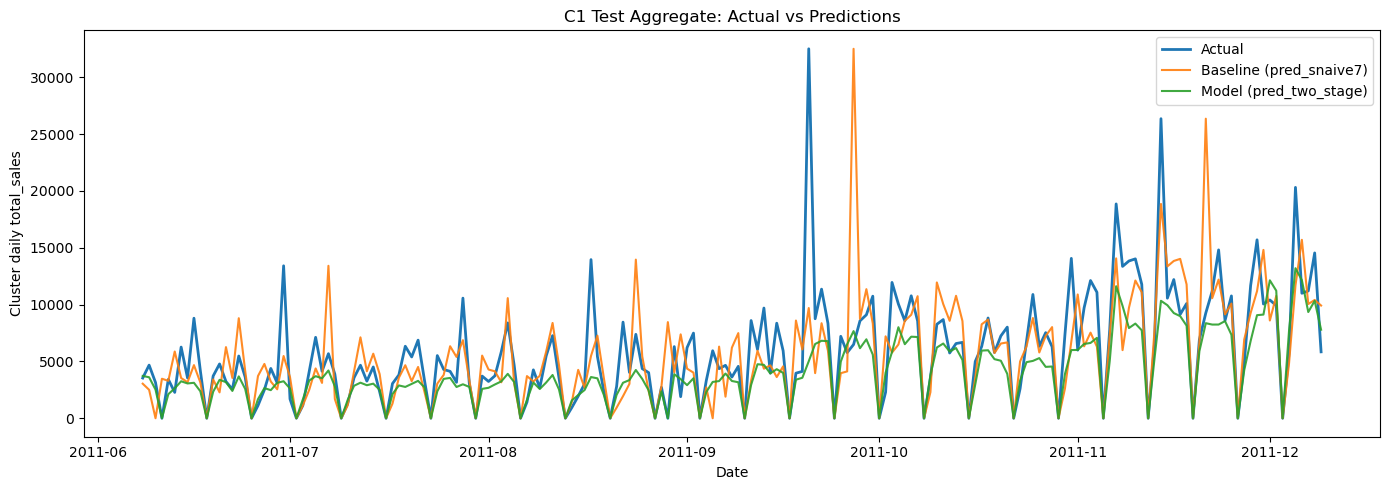

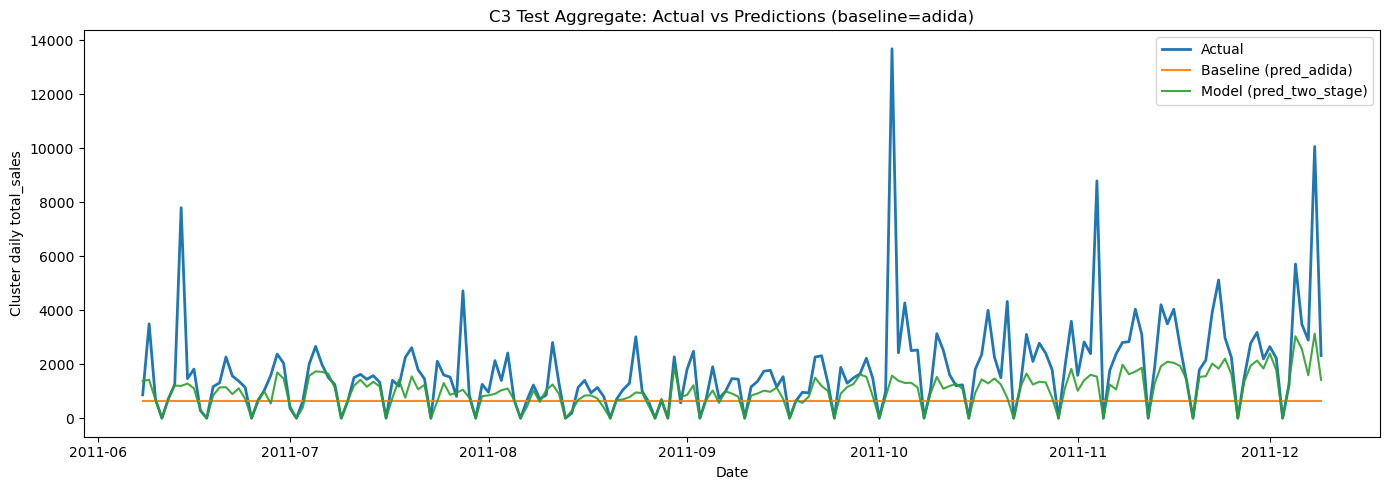

In [6]:
# ============================================
# 4) Optional: test-period MAPE pivot table for report
# ============================================

def period_metric_pivot(metrics_by_period: pd.DataFrame, metric_col: str):
    return (
        metrics_by_period
        .pivot(index="period", columns="method", values=metric_col)
        .reset_index()
        .sort_values("period")
    )

print("C1 period MAPE (0-100):")
display(period_metric_pivot(art_c1.metrics_by_period, "MAPE_0_100"))

print("C3 period MAPE (0-100):")
display(period_metric_pivot(art_c3.metrics_by_period, "MAPE_0_100"))

# ============================================
# 5) Optional: load saved prediction parquet files
# ============================================
c1_pred = pd.read_parquet("data/forecasting/c1_prediction.parquet")
c3_pred = pd.read_parquet("data/forecasting/c3_prediction.parquet")

print("c1_pred shape:", c1_pred.shape)
print("c3_pred shape:", c3_pred.shape)

display(c1_pred.head())
display(c3_pred.head())

# ============================================
# 6) Optional: actual vs prediction time-series (cluster aggregate, test only)
# ============================================

def plot_cluster_agg_ts(pred_df: pd.DataFrame, baseline_col: str, model_col: str, title: str):
    agg = (
        pred_df.groupby("date", as_index=False)[["y", baseline_col, model_col]]
        .sum()
        .sort_values("date")
    )

    plt.figure(figsize=(14, 5))
    plt.plot(agg["date"], agg["y"], label="Actual", linewidth=2)
    plt.plot(agg["date"], agg[baseline_col], label=f"Baseline ({baseline_col})", alpha=0.9)
    plt.plot(agg["date"], agg[model_col], label=f"Model ({model_col})", alpha=0.9)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Cluster daily total_sales")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_cluster_agg_ts(
    art_c1.pred_df,
    baseline_col="pred_snaive7",
    model_col="pred_two_stage",
    title="C1 Test Aggregate: Actual vs Predictions"
)

# For C3 baseline, use selected baseline name
c3_baseline_col_map = {
    "tsb": "pred_tsb",
    "sba": "pred_sba",
    "adida": "pred_adida",
}
c3_base_col = c3_baseline_col_map[art_c3.selected_baseline_name]

plot_cluster_agg_ts(
    art_c3.pred_df,
    baseline_col=c3_base_col,
    model_col="pred_two_stage",
    title=f"C3 Test Aggregate: Actual vs Predictions (baseline={art_c3.selected_baseline_name})"
)


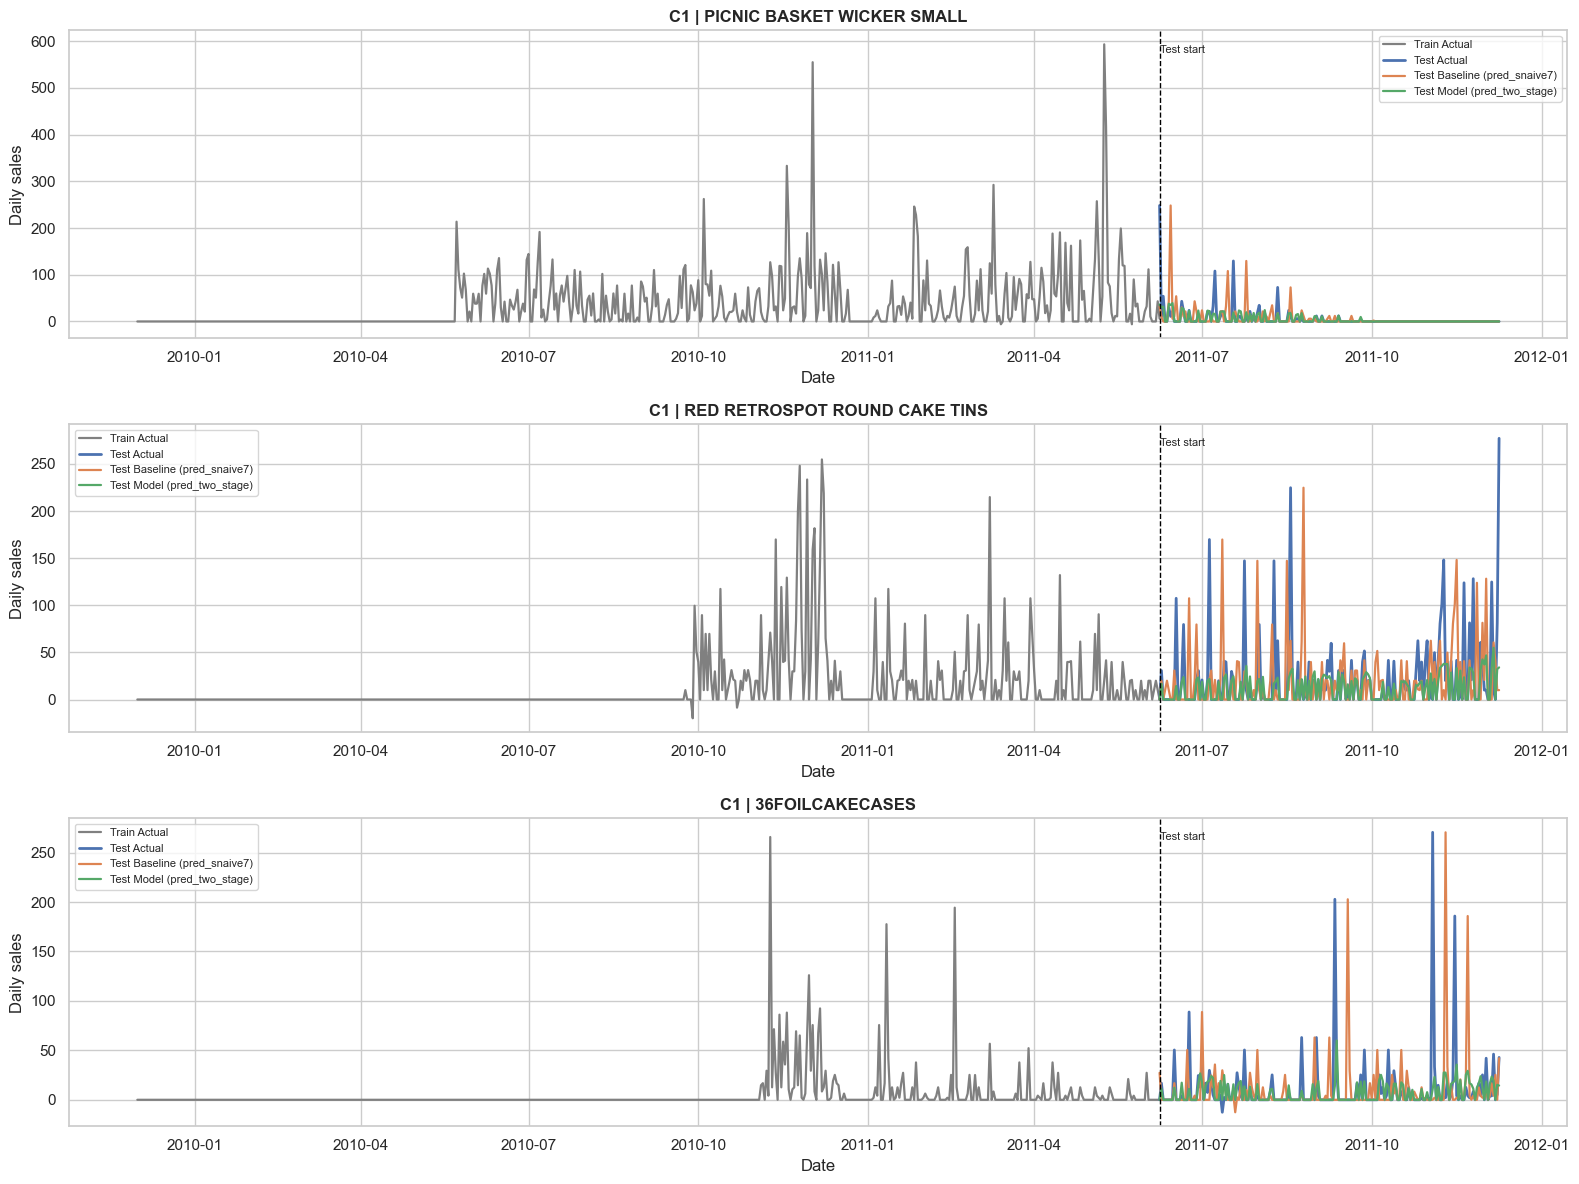

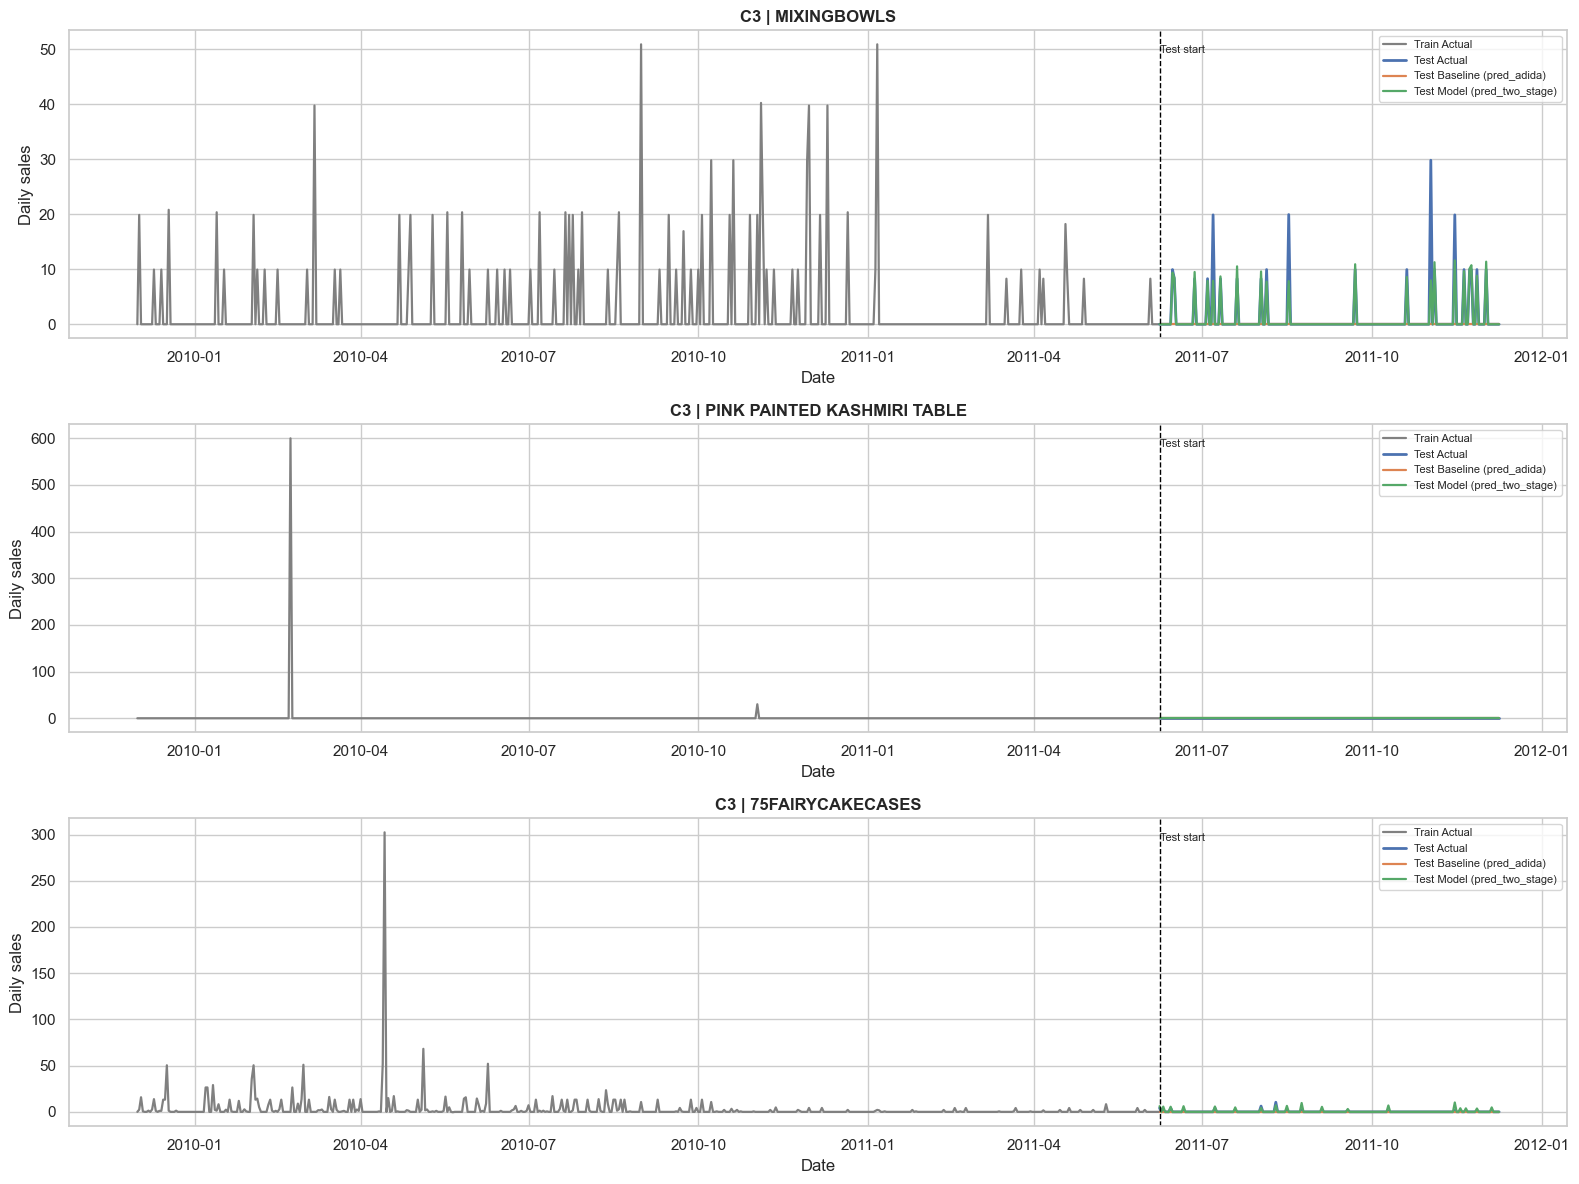

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_random_skus_train_test(
    art,
    cluster_label="C1",
    baseline_col="pred_snaive7",
    model_col="pred_two_stage",
    n_skus=3,
    random_state=123,
):
    rng = np.random.default_rng(random_state)

    train_df = art.train_panel.copy()   # columns: date, product_family_name, total_sales
    test_df = art.pred_df.copy()        # columns: date, product_family_name, y, baseline/model preds

    sku_list = test_df["product_family_name"].dropna().unique()
    n_pick = min(n_skus, len(sku_list))
    picked = rng.choice(sku_list, size=n_pick, replace=False)

    ncols = 1
    nrows = int(np.ceil(n_pick / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=False)
    axes = np.array(axes).reshape(-1)

    for i, sku in enumerate(picked):
        ax = axes[i]

        tr = train_df[train_df["product_family_name"] == sku].sort_values("date")
        te = test_df[test_df["product_family_name"] == sku].sort_values("date")

        # Training: only actual
        ax.plot(tr["date"], tr["total_sales"], color="gray", lw=1.6, label="Train Actual")

        # Testing: actual + baseline + model
        ax.plot(te["date"], te["y"], lw=2.0, label="Test Actual")
        ax.plot(te["date"], te[baseline_col], lw=1.6, label=f"Test Baseline ({baseline_col})")
        ax.plot(te["date"], te[model_col], lw=1.6, label=f"Test Model ({model_col})")

        # Mark train/test split
        if len(te) > 0:
            split_date = te["date"].min()
            ax.axvline(split_date, color="black", linestyle="--", lw=1)
            ax.text(split_date, ax.get_ylim()[1] * 0.95, "Test start", fontsize=8, va="top")

        ax.set_title(f"{cluster_label} | {sku}")
        ax.set_xlabel("Date")
        ax.set_ylabel("Daily sales")
        ax.legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# C1
plot_random_skus_train_test(
    art_c1,
    cluster_label="C1",
    baseline_col="pred_snaive7",
    model_col="pred_two_stage",
    n_skus=3
)

# C3 (baseline is dynamic)
c3_baseline_col = f"pred_{art_c3.selected_baseline_name}"
plot_random_skus_train_test(
    art_c3,
    cluster_label="C3",
    baseline_col=c3_baseline_col,
    model_col="pred_two_stage",
    n_skus=3
)


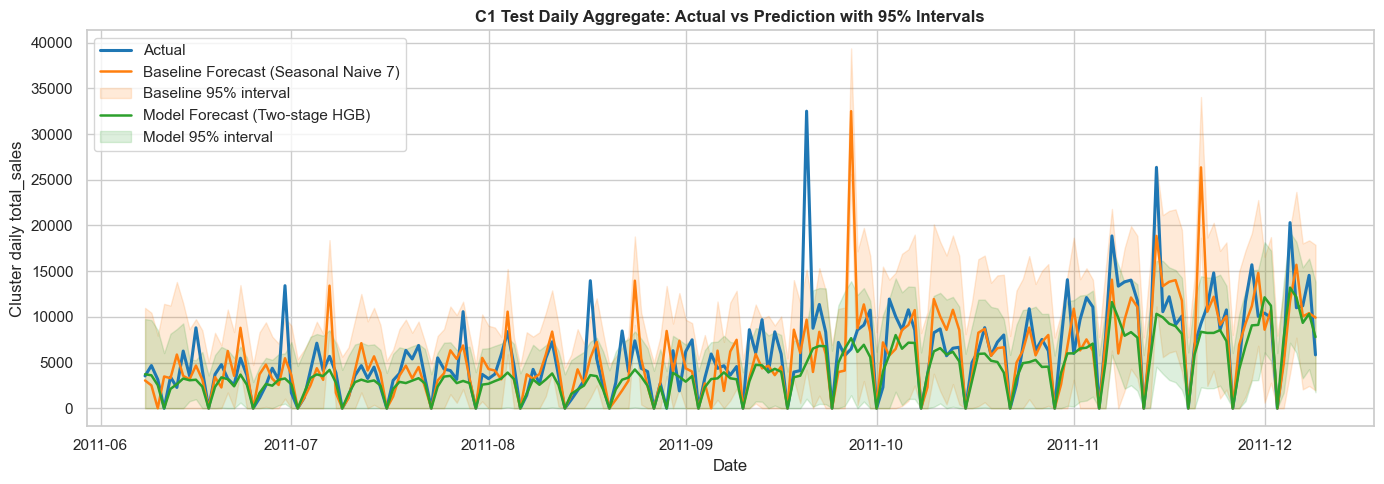

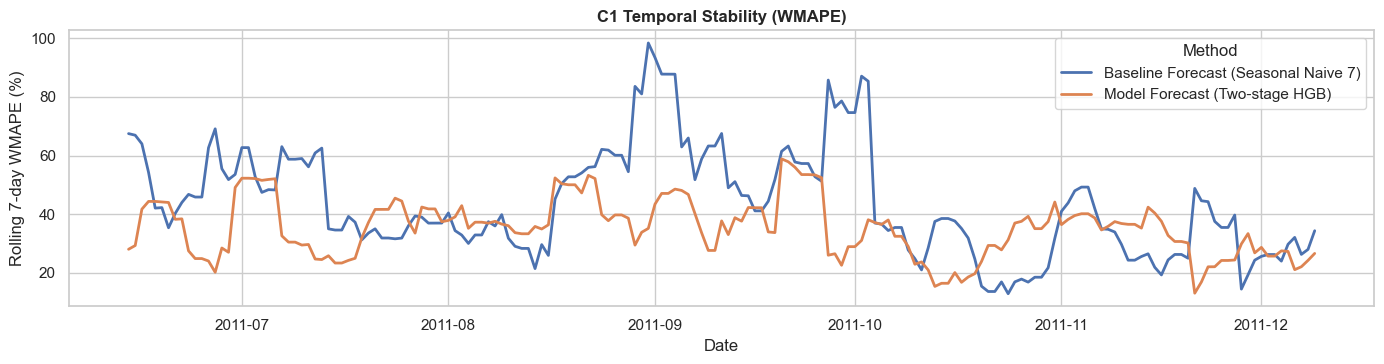

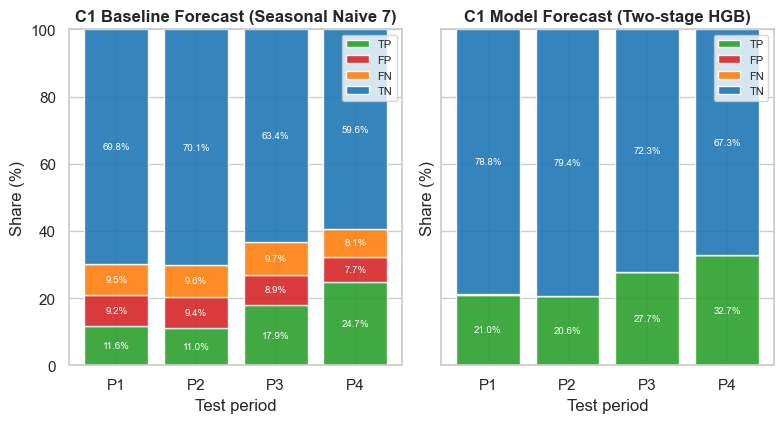

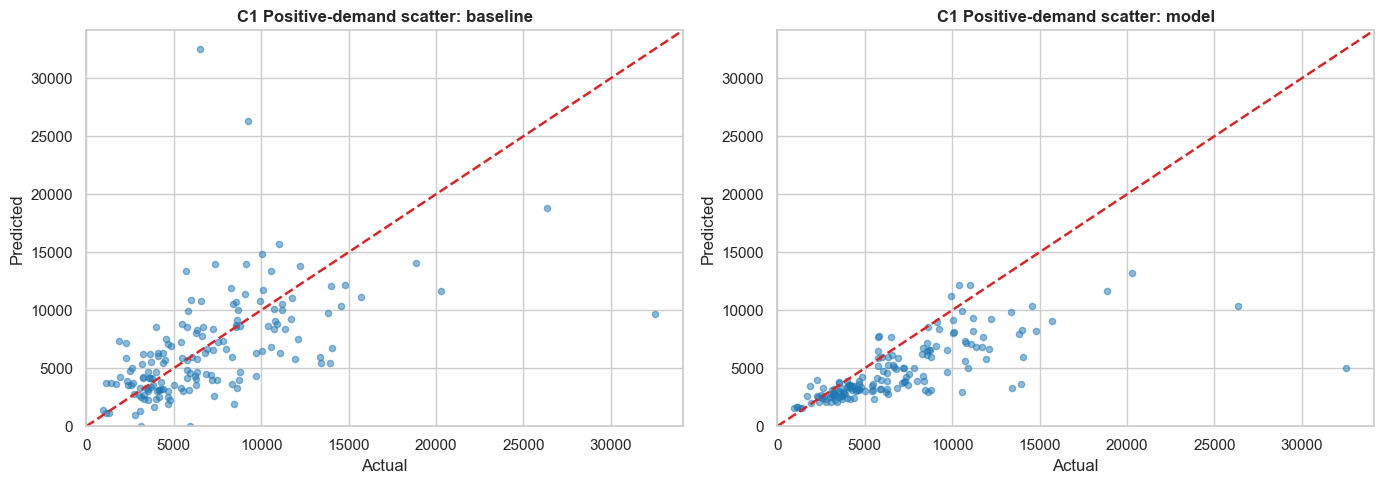

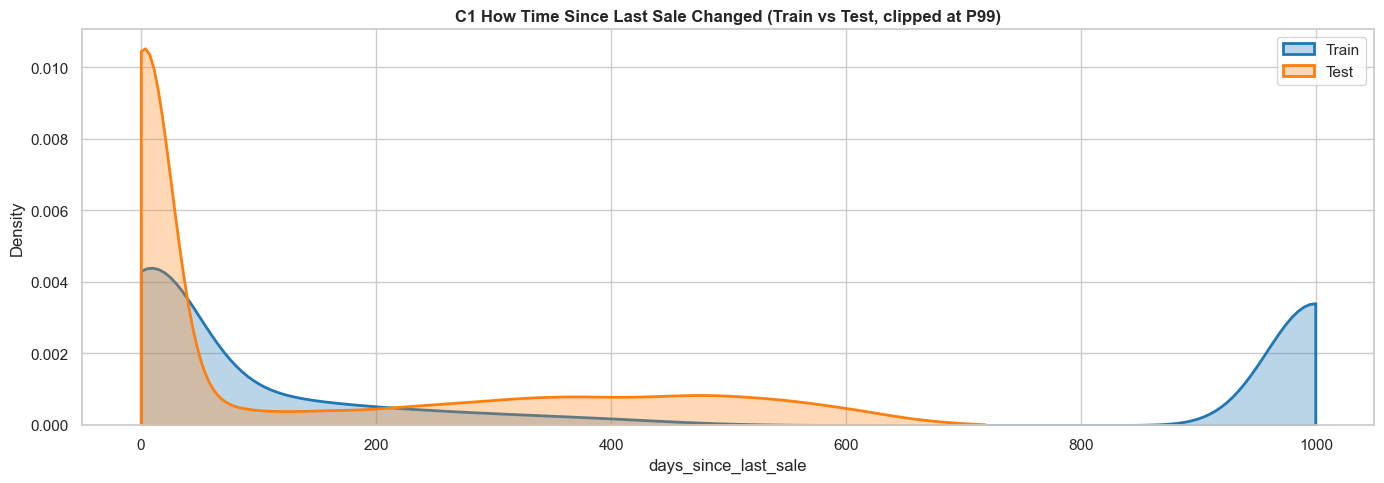

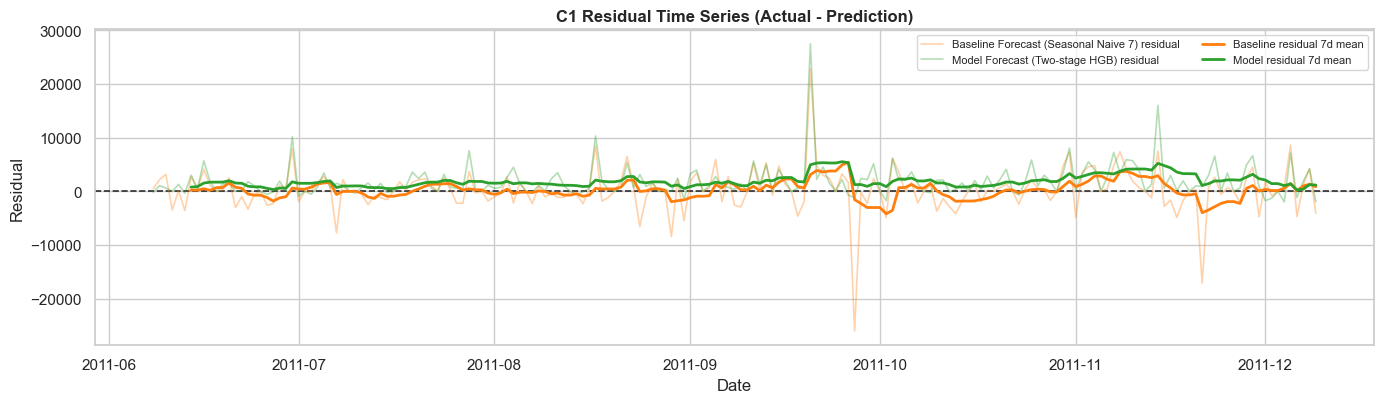

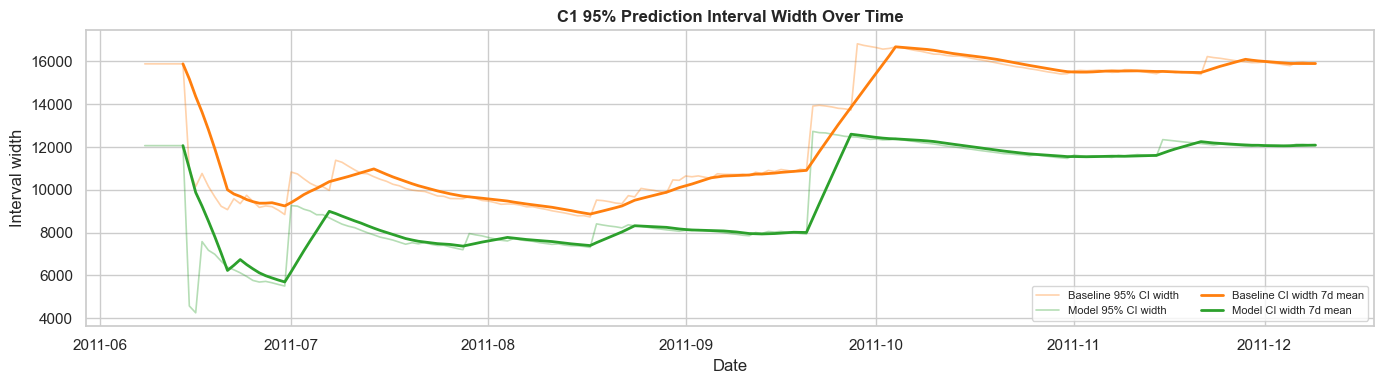

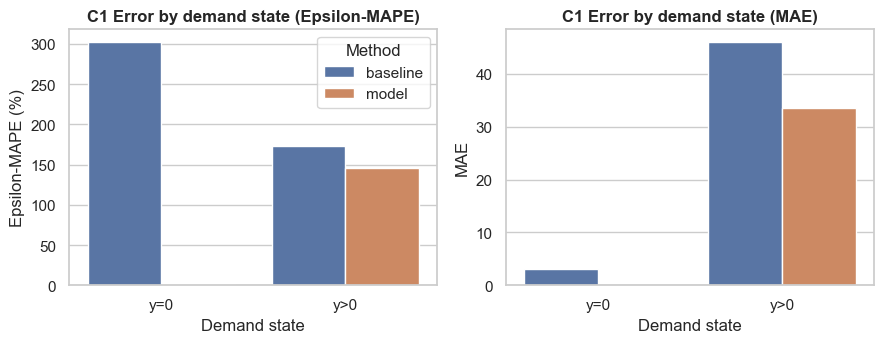

,method,wmape_pct,epsilon_mape_pct,cap_mape_0_100,tail_ape_p90,tail_ape_p95,pred_nonzero_rate,actual_nonzero_rate,nonzero_rate_gap,signed_pct_error_mean,signed_abs_bias_ratio
0,model,67.691523,38.547142,15.565231,75.887555,182.492012,0.255368,0.25482,0.000549,28.038148,-0.307166
1,baseline,111.075906,270.261428,28.671702,311.749020,1250.000000,0.250649,0.25482,-0.004171,235.774185,-0.042375


,method,period,TP,FP,FN,TN,TP_pct,FP_pct,FN_pct,TN_pct
0,baseline,P1,2569,2049,2103,15510,11.555935,9.216859,9.459763,69.767442
1,baseline,P2,2396,2036,2083,15243,11.012042,9.357478,9.573490,70.056991
2,baseline,P3,3903,1940,2119,13796,17.938230,8.916261,9.738947,63.406563
3,baseline,P4,5369,1671,1756,12962,24.675981,7.679934,8.070595,59.573490
4,model,P1,4672,48,0,17511,21.015699,0.215915,0.000000,78.768386
5,model,P2,4479,0,0,17279,20.585532,0.000000,0.000000,79.414468
6,model,P3,6022,0,0,15736,27.677176,0.000000,0.000000,72.322824
7,model,P4,7125,0,0,14633,32.746576,0.000000,0.000000,67.253424


,method,state,count,epsilon_mape_pct,wmape_pct,mae
0,baseline,y=0,64930,302.763807,1.965845e+07,3.027638
1,baseline,y>0,22298,173.466057,9.281290e+01,46.097491
2,model,y=0,64930,1.588136,1.031177e+05,0.015881
3,model,y>0,22298,145.432009,6.735724e+01,33.454400


,train_mean,test_mean,train_p90,test_p90,train_999_share,test_999_share
0,392.023446,140.713045,999.0,489.0,0.352262,0.0


In [ ]:
import c1c3_analysis
importlib.reload(c1c3_analysis)
from c1c3_analysis import run_cluster_analysis

# C1 analysis (do not save files)
c1_results = run_cluster_analysis(
    art=art_c1,
    cluster_tag="c1",
    baseline_col="pred_snaive7",
    model_col="pred_two_stage",
    rolling_metric="wmape",   # or "mape"
    rolling_window=7,
    eps=1.0,
    n_periods=4,
    save_svg=True,           # set True to save svg
    output_root="images",
)

display(c1_results["metric_table"])
display(c1_results["confusion_by_period"])
display(c1_results["error_decomposition"])
display(c1_results["distribution_shift_stats"])

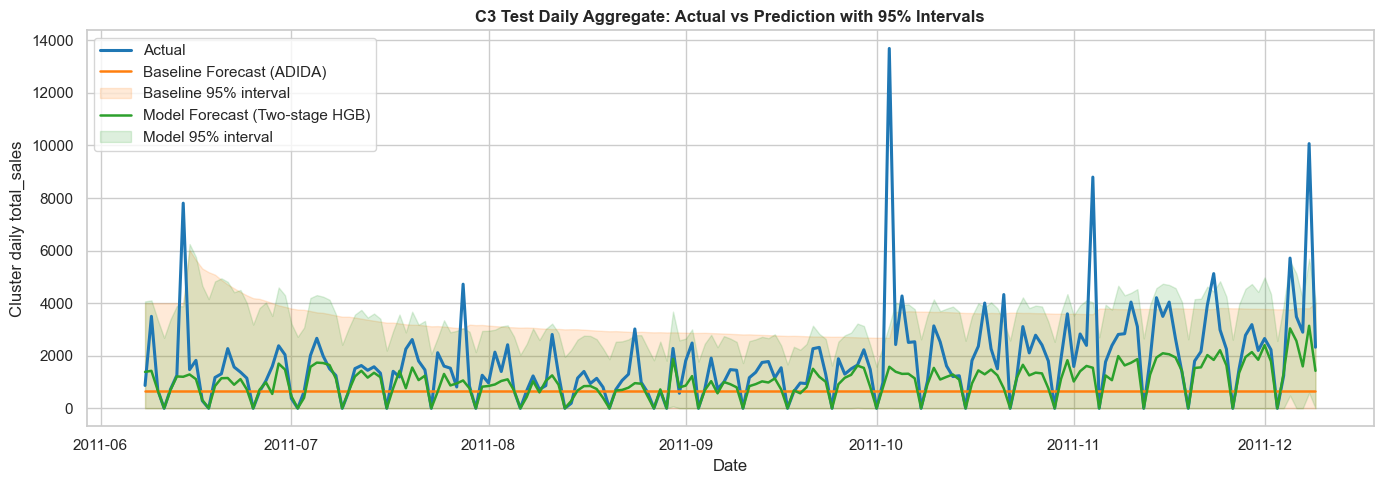

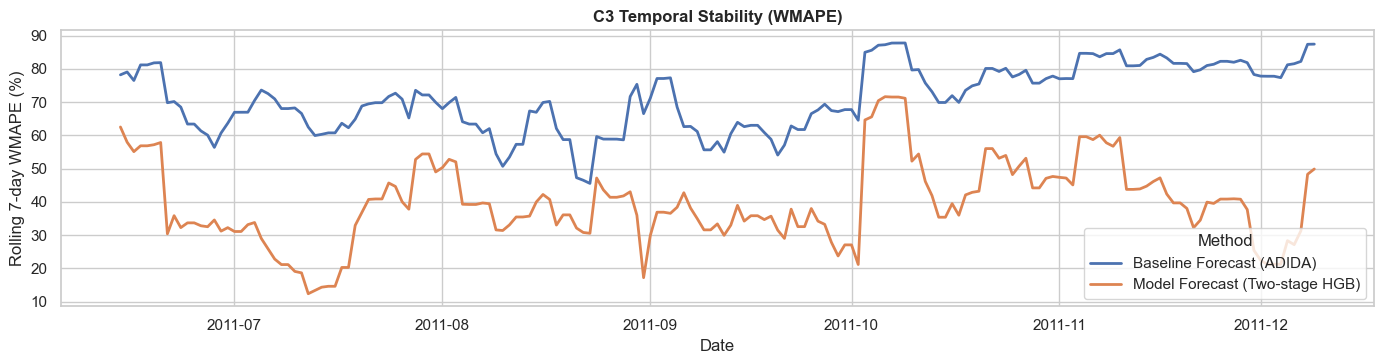

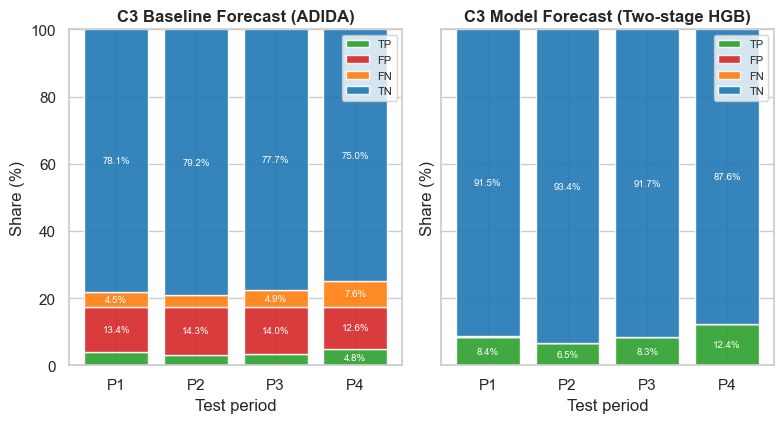

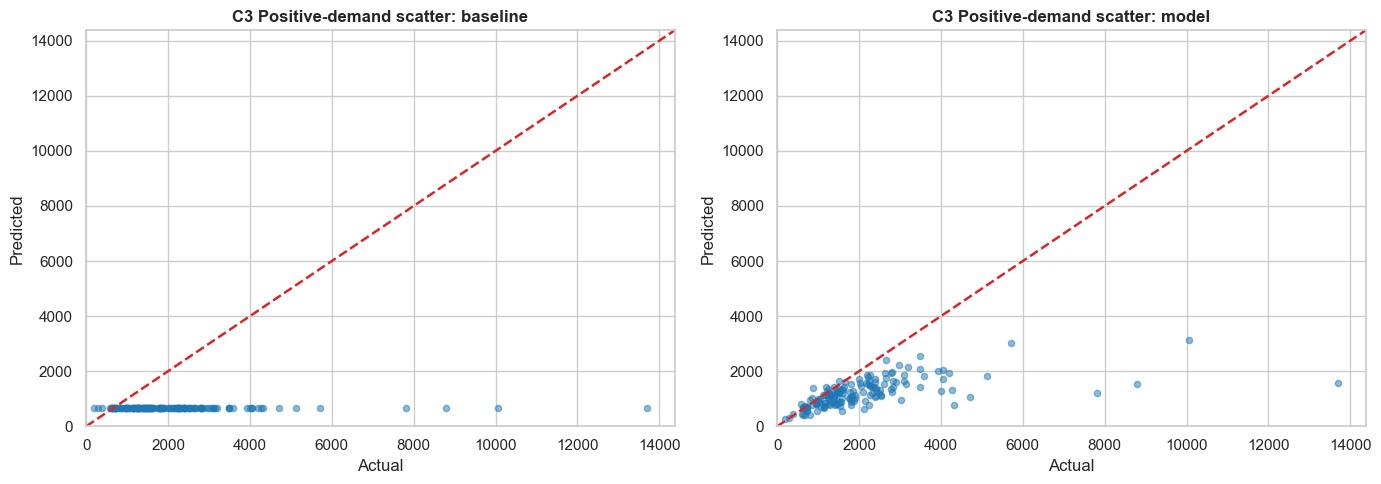

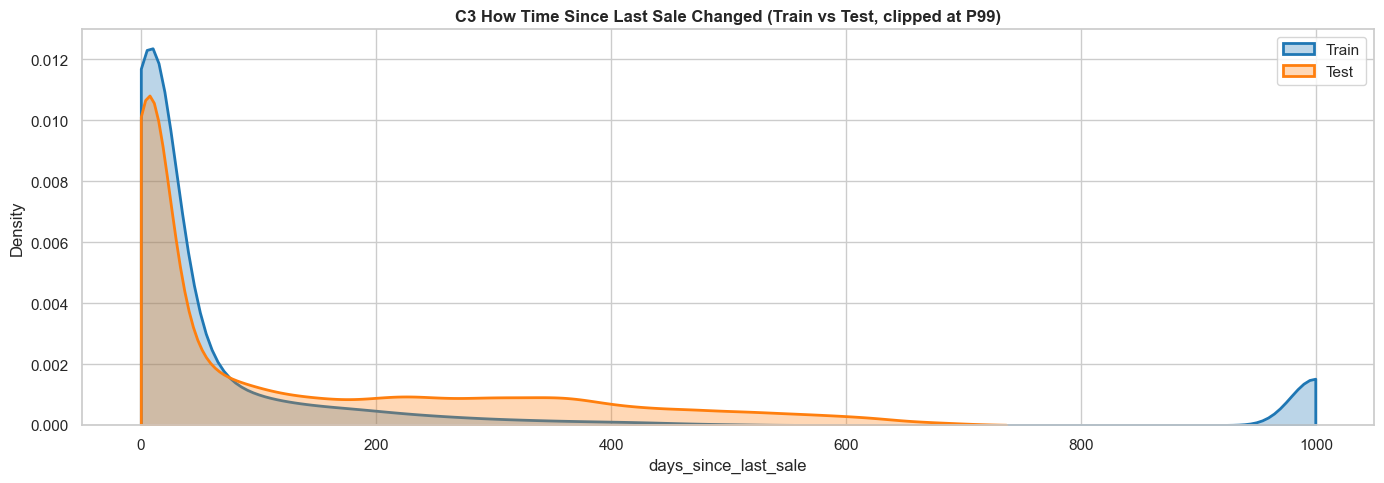

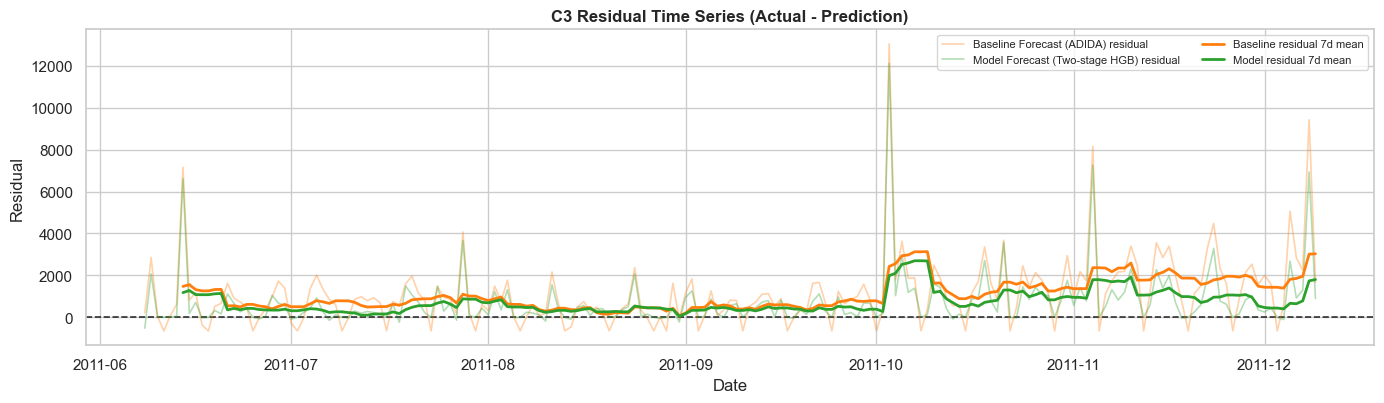

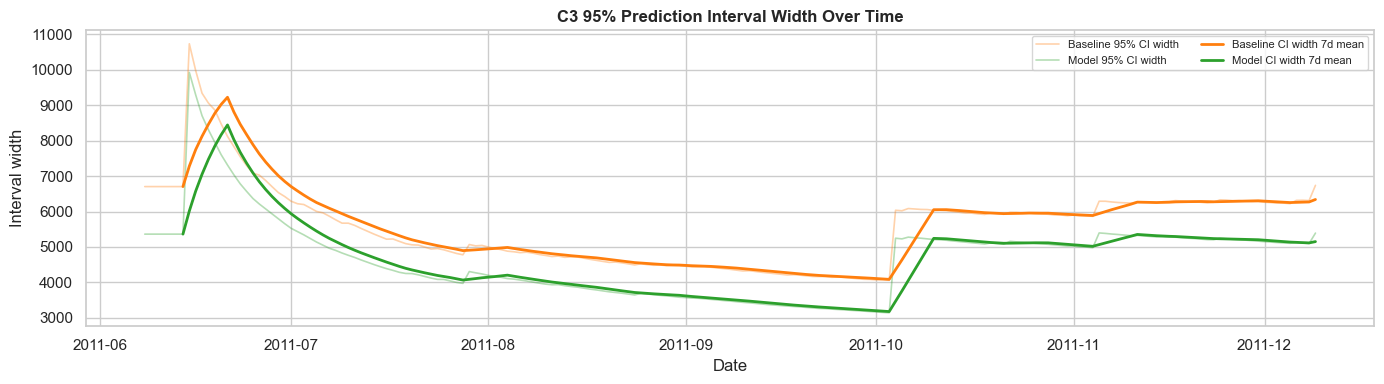

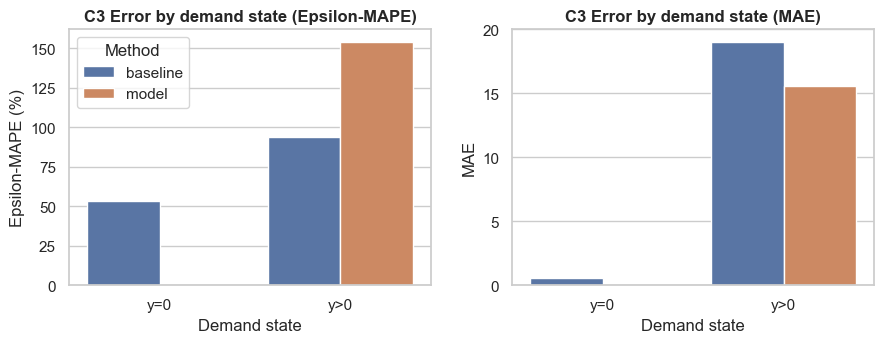

,method,wmape_pct,epsilon_mape_pct,cap_mape_0_100,tail_ape_p90,tail_ape_p95,pred_nonzero_rate,actual_nonzero_rate,nonzero_rate_gap,signed_pct_error_mean,signed_abs_bias_ratio
0,model,78.825801,14.124957,5.808878,0.0,60.150712,0.089224,0.089202,0.000021,10.946289,-0.408585
1,baseline,122.659748,56.768889,18.634981,100.0,180.000000,0.174041,0.089202,0.084839,41.709360,-0.615648


,method,period,TP,FP,FN,TN,TP_pct,FP_pct,FN_pct,TN_pct
0,baseline,P1,1899,6420,2146,37334,3.972886,13.431243,4.489634,78.106237
1,baseline,P2,1465,6677,1601,37039,3.131546,14.272583,3.422256,79.173614
2,baseline,P3,1595,6547,2295,36345,3.409431,13.994699,4.905733,77.690137
3,baseline,P4,2225,5917,3557,35083,4.756103,12.648027,7.603352,74.992518
4,model,P1,4031,39,14,43715,8.433231,0.081592,0.029289,91.455888
5,model,P2,3062,0,4,43716,6.545252,0.000000,0.008550,93.446197
6,model,P3,3874,0,16,42892,8.280963,0.000000,0.034201,91.684836
7,model,P4,5781,0,1,41000,12.357317,0.000000,0.002138,87.640546


,method,state,count,epsilon_mape_pct,wmape_pct,mae
0,baseline,y=0,171169,53.034153,9.077803e+06,0.530342
1,baseline,y>0,16783,94.075197,9.568222e+01,19.049436
2,model,y=0,171169,0.304621,5.214165e+04,0.003046
3,model,y>0,16783,154.116152,7.833042e+01,15.594856


,train_mean,test_mean,train_p90,test_p90,train_999_share,test_999_share
0,117.496729,133.450971,310.0,414.0,0.080022,0.0


In [ ]:
# C3 analysis (baseline inferred from selected baseline)
c3_baseline_col = f"pred_{art_c3.selected_baseline_name}"

c3_results = run_cluster_analysis(
    art=art_c3,
    cluster_tag="c3",
    baseline_col=c3_baseline_col,
    model_col="pred_two_stage",
    rolling_metric="wmape",
    rolling_window=7,
    eps=1.0,
    n_periods=4,
    save_svg=True,           # set True to save svg to images/c3_results
    output_root="images",
)

display(c3_results["metric_table"])
display(c3_results["confusion_by_period"])
display(c3_results["error_decomposition"])
display(c3_results["distribution_shift_stats"])